# Day 2 — 모델용 데이터 선정과 분자 특성 생성

이 노트북은 원본 BBBP 2,050행을 그대로 보존하면서 모델 학습에 사용할 분자를 결정합니다. canonical SMILES로 중복과 라벨 충돌을 검사한 뒤, 지정된 8개 molecular descriptor와 Morgan fingerprint를 생성합니다.

오늘은 **데이터 분할, 스케일링, 모델 학습과 성능 평가를 하지 않습니다.**

## 1. 실행 환경과 라이브러리 준비

**입력:** 현재 Python 환경과 Day 1에 설치한 라이브러리입니다.  
**출력:** 주요 라이브러리 버전, 프로젝트 루트와 결과 폴더를 출력합니다. Matplotlib 캐시는 Git에서 제외되는 `work/`에 두어 권한 문제를 예방합니다.

In [1]:
from pathlib import Path
import io
import logging
import os
import re
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
WORK_DIR = PROJECT_ROOT / "work"
RESULTS_DIR.mkdir(exist_ok=True)
WORK_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(WORK_DIR / "matplotlib-cache"))

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit
import seaborn as sns
from IPython.display import display
from rdkit import Chem, DataStructs, rdBase
from rdkit.Chem import Crippen, Descriptors, Lipinski, rdFingerprintGenerator, rdMolDescriptors

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

versions = pd.Series(
    {
        "Python": sys.version.split()[0],
        "NumPy": np.__version__,
        "pandas": pd.__version__,
        "RDKit": rdkit.__version__,
        "Matplotlib": matplotlib.__version__,
        "seaborn": sns.__version__,
    },
    name="version",
)
display(versions.to_frame())
print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"결과 폴더: {RESULTS_DIR}")

,version
Python,3.12.13
NumPy,2.5.2
pandas,3.0.5
RDKit,2026.03.5
Matplotlib,3.11.1
seaborn,0.13.2


프로젝트 루트: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp
결과 폴더: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results


## 2. 원본 데이터를 다시 불러오기

**입력:** Day 1과 동일한 DeepChem 공식 BBBP CSV URL입니다.  
**출력:** 원본 2,050행을 담은 `original_df`를 만들고 크기와 열 이름을 출력합니다. 원본 CSV를 로컬에 저장하지 않습니다.

`original_df`는 이후에도 행을 삭제하지 않는 기준 표입니다. 모델용 데이터는 항상 별도의 DataFrame으로 만듭니다.

In [2]:
DATA_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
EXPECTED_COLUMNS = ["num", "name", "p_np", "smiles"]

original_df = pd.read_csv(DATA_URL)
original_df["source_index"] = original_df.index

assert len(original_df) == 2050, "공식 BBBP 데이터의 행 수가 Day 1과 다릅니다. 출처 변경 여부를 확인하세요."
assert original_df.columns[:4].tolist() == EXPECTED_COLUMNS, "BBBP 열 구조가 Day 1과 다릅니다."
print(f"원본 데이터: {len(original_df):,}행 × {len(EXPECTED_COLUMNS)}개 원본 열")
print(f"원본 열: {EXPECTED_COLUMNS}")
display(original_df[EXPECTED_COLUMNS].head())

원본 데이터: 2,050행 × 4개 원본 열
원본 열: ['num', 'name', 'p_np', 'smiles']


,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)[C@@H](N4C3=O)C(O)=O


## 3. 원본 데이터와 모델 후보 데이터 구분

**입력:** `original_df`의 모든 SMILES입니다.  
**출력:** 모든 원본 행에 대한 파싱 결과를 가진 `parsing_audit_df`와, RDKit 파싱에 성공한 행만 복사한 `model_candidate_df`를 만듭니다.

실패한 11개는 원본에서 삭제되는 것이 아닙니다. 원본에는 그대로 남고, descriptor와 fingerprint를 계산할 수 없어 **모델 학습 대상에서 제외**됩니다. 오류 로그는 행별로 수집하며 RDKit 경고를 전체 비활성화하지 않습니다.

In [3]:
rdBase.LogToPythonLogger()
rdkit_logger = logging.getLogger("rdkit")
rdkit_logger.setLevel(logging.ERROR)
original_log_handlers = rdkit_logger.handlers[:]
for existing_handler in original_log_handlers:
    rdkit_logger.removeHandler(existing_handler)

def parse_smiles_with_reason(smiles):
    """SMILES를 RDKit Mol로 변환하고 실패 이유를 함께 반환합니다."""
    if pd.isna(smiles):
        return None, "SMILES 값이 비어 있습니다."

    log_stream = io.StringIO()
    log_handler = logging.StreamHandler(log_stream)
    log_handler.setLevel(logging.ERROR)
    rdkit_logger.addHandler(log_handler)
    try:
        mol = Chem.MolFromSmiles(str(smiles))
    except Exception as exc:
        mol = None
        log_stream.write(f"{type(exc).__name__}: {exc}")
    finally:
        rdkit_logger.removeHandler(log_handler)

    cleaned_lines = []
    for line in log_stream.getvalue().splitlines():
        cleaned = re.sub(r"^\[\d{2}:\d{2}:\d{2}\]\s*", "", line.strip())
        if cleaned:
            cleaned_lines.append(cleaned)
    error_message = " | ".join(cleaned_lines)
    if mol is None and not error_message:
        error_message = "RDKit이 분자 객체를 반환하지 않았습니다."
    return mol, error_message

parse_results = original_df["smiles"].map(parse_smiles_with_reason)
parsing_audit_df = original_df.copy()
parsing_audit_df["mol"] = parse_results.map(lambda result: result[0])
parsing_audit_df["parse_error"] = parse_results.map(lambda result: result[1])
parsing_audit_df["parse_ok"] = parsing_audit_df["mol"].notna()

for original_handler in original_log_handlers:
    rdkit_logger.addHandler(original_handler)

model_candidate_df = parsing_audit_df.loc[parsing_audit_df["parse_ok"]].copy()
original_count = len(original_df)
parse_success_count = len(model_candidate_df)
parse_failure_count = int((~parsing_audit_df["parse_ok"]).sum())

assert original_count == parse_success_count + parse_failure_count
assert parse_failure_count == 11, "Day 1과 파싱 실패 개수가 다릅니다. RDKit 또는 데이터 버전을 확인하세요."
print(f"원본 행: {original_count:,}")
print(f"RDKit 파싱 성공 — 모델 후보: {parse_success_count:,}")
print(f"RDKit 파싱 실패 — 모델 학습 대상에서 제외: {parse_failure_count:,}")

원본 행: 2,050
RDKit 파싱 성공 — 모델 후보: 2,039
RDKit 파싱 실패 — 모델 학습 대상에서 제외: 11


## 4. Canonical SMILES 생성

**입력:** 파싱에 성공한 RDKit `Mol` 객체입니다.  
**출력:** 각 분자를 일정한 규칙으로 다시 쓴 `canonical_smiles` 열과 생성 실패 개수를 출력합니다.

원본 SMILES는 같은 분자를 여러 가지 순서로 쓸 수 있습니다. 예를 들어 원자 작성 순서나 고리 번호가 달라도 같은 구조일 수 있습니다. canonical SMILES는 RDKit이 동일한 규칙으로 다시 작성한 대표 문자열이므로 중복 구조를 찾는 데 유용합니다. `isomericSmiles=True`를 사용해 원본에 포함된 입체화학 표시는 가능한 범위에서 유지하지만, 원본에 없던 입체정보를 새로 만들지는 않습니다.

In [4]:
def make_canonical_smiles(mol):
    """RDKit Mol을 입체화학 표시를 유지한 canonical SMILES로 변환합니다."""
    try:
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return None

model_candidate_df["canonical_smiles"] = model_candidate_df["mol"].map(make_canonical_smiles)
canonical_failure_mask = model_candidate_df["canonical_smiles"].isna() | model_candidate_df["canonical_smiles"].eq("")
canonical_failure_count = int(canonical_failure_mask.sum())

assert canonical_failure_count == 0, "Canonical SMILES 생성 실패가 있습니다. 해당 행을 확인하세요."
print(f"Canonical SMILES 생성 성공: {len(model_candidate_df) - canonical_failure_count:,}")
print(f"Canonical SMILES 생성 실패: {canonical_failure_count:,}")
display(model_candidate_df[["smiles", "canonical_smiles"]].head())

Canonical SMILES 생성 성공: 2,039
Canonical SMILES 생성 실패: 0


,smiles,canonical_smiles
0,[Cl].CC(C)NCC(O)COc1cccc2ccccc12,CC(C)NCC(O)COc1cccc2ccccc12.[Cl]
1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1
2,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23
3,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C,CC(=O)NCCCOc1cccc(CN2CCCCC2)c1
4,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)[C@@H](N4C3=O)C(O)=O,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H]1SC(C)(C)[C@@H]2C(=O)O


## 5. Canonical SMILES 중복과 라벨 충돌 검사

**입력:** `model_candidate_df`의 canonical SMILES와 `p_np` 라벨입니다.  
**출력:** 중복 그룹 수, 중복 관련 행 수, 동일 라벨 중복과 라벨 충돌을 구분한 표를 만들고 다음 CSV를 저장합니다.

- `day2_duplicate_smiles.csv`: 중복 그룹에 속한 모든 행
- `day2_conflicting_labels.csv`: 같은 canonical SMILES인데 라벨이 다른 그룹의 모든 행

여기서 **중복 그룹 수**는 두 행 이상을 가진 canonical SMILES의 종류 수이고, **중복 관련 행 수**는 그 그룹들에 포함된 전체 행 수입니다. **중복 초과 행 수**는 각 그룹에서 한 행만 남긴다고 가정할 때 추가로 남는 행 수입니다. 결과가 없더라도 열 이름을 가진 빈 CSV가 생성되도록 합니다.

In [5]:
group_stats = (
    model_candidate_df.groupby("canonical_smiles")
    .agg(group_size=("canonical_smiles", "size"), unique_label_count=("p_np", "nunique"))
    .reset_index()
)
duplicate_group_stats = group_stats.loc[group_stats["group_size"] > 1].copy()
duplicate_keys = set(duplicate_group_stats["canonical_smiles"])
conflicting_keys = set(
    duplicate_group_stats.loc[duplicate_group_stats["unique_label_count"] > 1, "canonical_smiles"]
)
same_label_duplicate_keys = duplicate_keys - conflicting_keys

duplicate_columns = [
    "source_index", "num", "name", "p_np", "class", "smiles",
    "canonical_smiles", "group_size", "unique_label_count", "duplicate_type",
]
duplicate_smiles = model_candidate_df.loc[
    model_candidate_df["canonical_smiles"].isin(duplicate_keys),
    ["source_index", "num", "name", "p_np", "smiles", "canonical_smiles"],
].copy()

if duplicate_smiles.empty:
    duplicate_smiles = pd.DataFrame(columns=duplicate_columns)
else:
    duplicate_smiles = duplicate_smiles.merge(duplicate_group_stats, on="canonical_smiles", how="left")
    duplicate_smiles["class"] = duplicate_smiles["p_np"].map({0: "BBB-", 1: "BBB+"})
    duplicate_smiles["duplicate_type"] = np.where(
        duplicate_smiles["unique_label_count"] > 1,
        "conflicting_labels",
        "same_label_duplicate",
    )
    duplicate_smiles = duplicate_smiles[duplicate_columns].sort_values(
        ["duplicate_type", "canonical_smiles", "source_index"]
    )

conflicting_labels = duplicate_smiles.loc[
    duplicate_smiles["duplicate_type"] == "conflicting_labels"
].copy()
if conflicting_labels.empty:
    conflicting_labels = pd.DataFrame(columns=duplicate_columns)

duplicate_path = RESULTS_DIR / "day2_duplicate_smiles.csv"
conflict_path = RESULTS_DIR / "day2_conflicting_labels.csv"
duplicate_smiles.to_csv(duplicate_path, index=False, encoding="utf-8")
conflicting_labels.to_csv(conflict_path, index=False, encoding="utf-8")

duplicate_group_count = len(duplicate_group_stats)
duplicate_rows_involved = len(duplicate_smiles)
redundant_duplicate_rows = int((duplicate_group_stats["group_size"] - 1).sum())
same_label_duplicate_group_count = len(same_label_duplicate_keys)
conflicting_group_count = len(conflicting_keys)
conflicting_rows_excluded = len(conflicting_labels)
same_label_duplicate_excluded = int(
    (duplicate_group_stats.loc[
        duplicate_group_stats["canonical_smiles"].isin(same_label_duplicate_keys), "group_size"
    ] - 1).sum()
)

duplicate_report = pd.DataFrame(
    {
        "metric": [
            "duplicate_group_count", "duplicate_rows_involved", "redundant_duplicate_rows",
            "same_label_duplicate_group_count", "same_label_duplicate_excluded_rows",
            "conflicting_label_group_count", "conflicting_label_excluded_rows",
        ],
        "value": [
            duplicate_group_count, duplicate_rows_involved, redundant_duplicate_rows,
            same_label_duplicate_group_count, same_label_duplicate_excluded,
            conflicting_group_count, conflicting_rows_excluded,
        ],
    }
)
display(duplicate_report)
print(f"중복 행 CSV: {duplicate_path}")
print(f"라벨 충돌 CSV: {conflict_path}")

,metric,value
0,duplicate_group_count,60
1,duplicate_rows_involved,124
2,redundant_duplicate_rows,64
3,same_label_duplicate_group_count,50
4,same_label_duplicate_excluded_rows,54
5,conflicting_label_group_count,10
6,conflicting_label_excluded_rows,20


중복 행 CSV: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day2_duplicate_smiles.csv
라벨 충돌 CSV: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day2_conflicting_labels.csv


## 6. 중복·충돌 처리 후 최종 모델용 데이터 결정

**입력:** 중복과 라벨 충돌 검사가 끝난 `model_candidate_df`입니다.  
**출력:** 라벨 충돌 그룹은 모든 행을 모델 대상에서 제외하고, 동일 라벨 중복 그룹은 원본 순서상 첫 행 하나만 유지한 `final_model_df`를 만듭니다. 처리 수치는 `day2_data_cleaning_summary.csv`에 저장합니다.

라벨 충돌은 어느 라벨이 맞는지 이 데이터만으로 판단할 수 없으므로 임의로 수정하지 않습니다. `original_df`와 `model_candidate_df`는 그대로 유지되고, 새 DataFrame에서만 모델 입력 대상을 선택합니다.

In [6]:
without_conflicts_df = model_candidate_df.loc[
    ~model_candidate_df["canonical_smiles"].isin(conflicting_keys)
].copy()
final_model_df = (
    without_conflicts_df
    .sort_values("source_index")
    .drop_duplicates(subset="canonical_smiles", keep="first")
    .reset_index(drop=True)
)
final_model_count = len(final_model_df)
final_class_counts = final_model_df["p_np"].value_counts().sort_index()
final_bbb_minus_count = int(final_class_counts.get(0, 0))
final_bbb_plus_count = int(final_class_counts.get(1, 0))
final_bbb_minus_percent = final_bbb_minus_count / final_model_count * 100
final_bbb_plus_percent = final_bbb_plus_count / final_model_count * 100

assert parse_success_count == same_label_duplicate_excluded + conflicting_rows_excluded + final_model_count
assert original_count == parse_failure_count + same_label_duplicate_excluded + conflicting_rows_excluded + final_model_count
assert final_model_df["canonical_smiles"].is_unique

cleaning_summary = pd.DataFrame(
    [
        {"metric": "original_rows", "value": original_count},
        {"metric": "parse_success_rows", "value": parse_success_count},
        {"metric": "parse_failure_excluded_rows", "value": parse_failure_count},
        {"metric": "canonical_failure_rows", "value": canonical_failure_count},
        {"metric": "duplicate_group_count", "value": duplicate_group_count},
        {"metric": "duplicate_rows_involved", "value": duplicate_rows_involved},
        {"metric": "redundant_duplicate_rows", "value": redundant_duplicate_rows},
        {"metric": "same_label_duplicate_group_count", "value": same_label_duplicate_group_count},
        {"metric": "same_label_duplicate_excluded_rows", "value": same_label_duplicate_excluded},
        {"metric": "conflicting_label_group_count", "value": conflicting_group_count},
        {"metric": "conflicting_label_excluded_rows", "value": conflicting_rows_excluded},
        {"metric": "final_model_rows", "value": final_model_count},
        {"metric": "final_BBB+_count", "value": final_bbb_plus_count},
        {"metric": "final_BBB+_percent", "value": round(final_bbb_plus_percent, 2)},
        {"metric": "final_BBB-_count", "value": final_bbb_minus_count},
        {"metric": "final_BBB-_percent", "value": round(final_bbb_minus_percent, 2)},
    ]
)
cleaning_summary_path = RESULTS_DIR / "day2_data_cleaning_summary.csv"
cleaning_summary.to_csv(cleaning_summary_path, index=False, encoding="utf-8")
display(cleaning_summary)
print(f"최종 모델용 분자: {final_model_count:,}")

,metric,value
0,original_rows,2050.00
1,parse_success_rows,2039.00
2,parse_failure_excluded_rows,11.00
3,canonical_failure_rows,0.00
4,duplicate_group_count,60.00
5,duplicate_rows_involved,124.00
6,redundant_duplicate_rows,64.00
7,same_label_duplicate_group_count,50.00
8,same_label_duplicate_excluded_rows,54.00
9,conflicting_label_group_count,10.00


최종 모델용 분자: 1,965


## 7. 사용할 8개 molecular descriptor

Descriptor는 분자 하나를 몇 개의 해석 가능한 숫자로 요약한 것입니다. 아래 관련성은 생물학적 가능성을 설명하는 것이며, 이 데이터에서 인과관계를 확정한다는 뜻은 아닙니다.

| Descriptor | 화학적·생물학적 의미 | BBB 투과성과 관련될 수 있는 이유 | 단위 |
|---|---|---|---|
| MolWt | 분자량 | 매우 큰 분자는 수동 확산이 어려울 수 있음 | g/mol |
| MolLogP | 옥탄올/물 분배계수의 로그 추정값, 지용성 지표 | 지질막에 분배되는 경향과 관련될 수 있음 | 없음 |
| TPSA | 극성 원자가 차지하는 위상학적 표면적 | 극성이 높으면 지질막 통과가 제한될 수 있음 | Å² |
| NumHDonors | 수소결합을 제공할 수 있는 작용기 수 | 물과의 상호작용 및 극성과 관련될 수 있음 | 개수, 단위 없음 |
| NumHAcceptors | 수소결합을 받을 수 있는 원자 수 | 물과의 상호작용 및 극성과 관련될 수 있음 | 개수, 단위 없음 |
| NumRotatableBonds | 자유롭게 회전 가능한 결합 수 | 분자 유연성과 막 통과 시 형태 변화에 관련될 수 있음 | 개수, 단위 없음 |
| RingCount | 분자 내 고리 수 | 강직성·형태·방향족성 같은 구조 특성과 관련될 수 있음 | 개수, 단위 없음 |
| FractionCSP3 | 탄소 중 sp3 혼성 탄소의 비율 | 분자의 포화도와 3차원적 형태를 나타냄 | 0~1 비율, 단위 없음 |

### Descriptor 계산과 품질 검사

**입력:** 최종 모델용 분자의 RDKit `Mol` 객체입니다.  
**출력:** 1,965행 × 8열 descriptor 행렬과 평균·표준편차·최솟값·중앙값·최댓값 표를 만듭니다. 행·열 수, NaN, 무한대와 숫자 자료형 여부를 assert로 검증합니다.

In [7]:
DESCRIPTOR_NAMES = [
    "MolWt", "MolLogP", "TPSA", "NumHDonors",
    "NumHAcceptors", "NumRotatableBonds", "RingCount", "FractionCSP3",
]

def calculate_descriptors(mol):
    """한 분자의 지정된 8개 descriptor를 dictionary로 반환합니다."""
    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "NumHDonors": Lipinski.NumHDonors(mol),
        "NumHAcceptors": Lipinski.NumHAcceptors(mol),
        "NumRotatableBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": Lipinski.RingCount(mol),
        "FractionCSP3": Descriptors.FractionCSP3(mol),
    }

descriptor_df = pd.DataFrame(
    [calculate_descriptors(mol) for mol in final_model_df["mol"]],
    columns=DESCRIPTOR_NAMES,
)
descriptor_shape = descriptor_df.shape
descriptor_has_nan = bool(descriptor_df.isna().any().any())
descriptor_all_finite = bool(np.isfinite(descriptor_df.to_numpy()).all())
descriptor_all_numeric = all(pd.api.types.is_numeric_dtype(descriptor_df[column]) for column in descriptor_df.columns)

assert descriptor_shape[0] == final_model_count
assert descriptor_shape[1] == 8
assert not descriptor_has_nan
assert descriptor_all_finite
assert descriptor_all_numeric

descriptor_summary = (
    descriptor_df.agg(["mean", "std", "min", "median", "max"])
    .T
    .reset_index(names="descriptor")
)
descriptor_summary_path = RESULTS_DIR / "day2_descriptor_summary.csv"
descriptor_summary.to_csv(descriptor_summary_path, index=False, encoding="utf-8")

print(f"Descriptor 행렬 shape: {descriptor_shape}")
print(f"NaN 존재: {descriptor_has_nan}")
print(f"모든 값이 유한함: {descriptor_all_finite}")
print(f"모든 열이 숫자 자료형: {descriptor_all_numeric}")
display(descriptor_summary.round(3))

Descriptor 행렬 shape: (1965, 8)
NaN 존재: False
모든 값이 유한함: True
모든 열이 숫자 자료형: True


,descriptor,mean,std,min,median,max
0,MolWt,346.793,151.807,28.054,325.456,1879.680
1,MolLogP,2.299,2.106,-11.745,2.466,10.813
2,TPSA,71.699,59.027,0.000,56.790,662.410
3,NumHDonors,1.567,1.862,0.000,1.000,24.000
4,NumHAcceptors,4.487,3.235,0.000,4.000,33.000
5,NumRotatableBonds,4.208,3.061,0.000,4.000,35.000
6,RingCount,3.009,1.554,0.000,3.000,16.000
7,FractionCSP3,0.464,0.231,0.000,0.429,1.000


## 8. BBB 클래스별 descriptor 분포 시각화

**입력:** 최종 모델용 분자의 MolWt, MolLogP, TPSA와 BBB 라벨입니다.  
**출력:** BBB+와 BBB-의 세 descriptor 분포를 밀도로 비교하고 `day2_descriptor_distributions.png`에 저장합니다. 두 클래스의 표본 수가 다르므로 단순 개수 대신 각 클래스 내부 분포 모양을 비교할 수 있는 density를 사용합니다.

MolWt         MolLogP           TPSA        
             mean  median    mean median    mean  median
bbb_class                                               
BBB+       317.50  308.57    2.67   2.79   54.13   47.89
BBB-       441.29  409.32    1.11   1.23  128.38  111.10

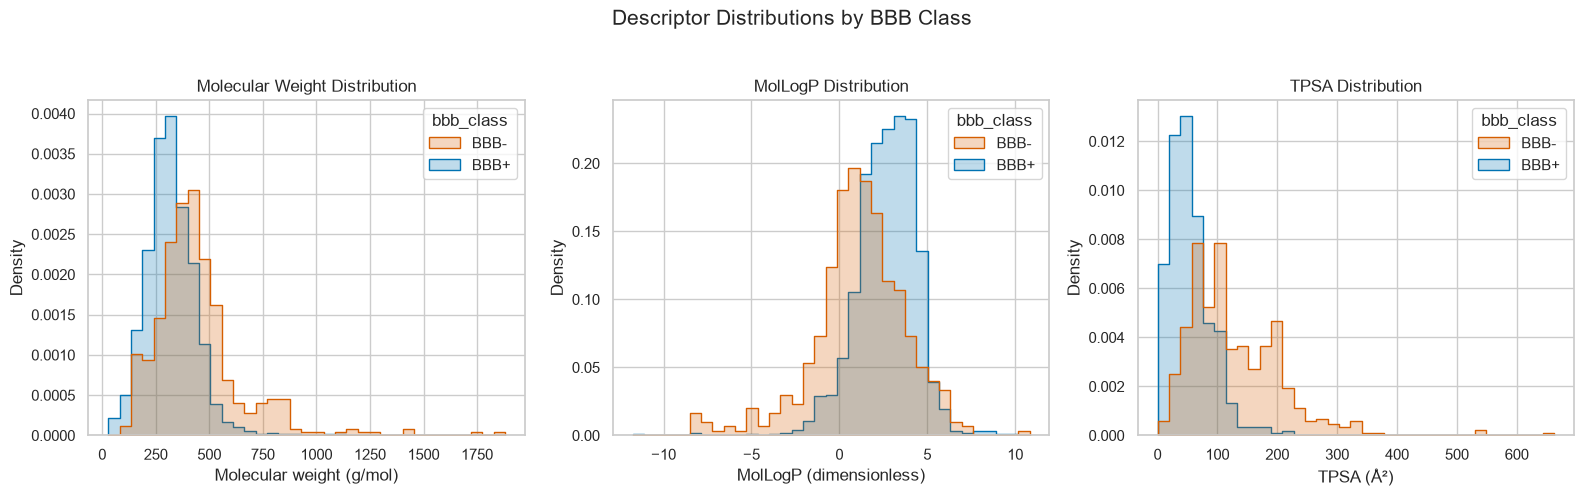

저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day2_descriptor_distributions.png


In [8]:
plot_df = descriptor_df.copy()
plot_df["bbb_class"] = final_model_df["p_np"].map({0: "BBB-", 1: "BBB+"}).to_numpy()
class_palette = {"BBB-": "#D55E00", "BBB+": "#0072B2"}
class_descriptor_stats = (
    plot_df.groupby("bbb_class")[["MolWt", "MolLogP", "TPSA"]]
    .agg(["mean", "median"])
    .round(2)
)
display(class_descriptor_stats)
distribution_settings = [
    ("MolWt", "Molecular Weight Distribution", "Molecular weight (g/mol)"),
    ("MolLogP", "MolLogP Distribution", "MolLogP (dimensionless)"),
    ("TPSA", "TPSA Distribution", "TPSA (Å²)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for axis, (column, title, x_label) in zip(axes, distribution_settings):
    sns.histplot(
        data=plot_df, x=column, hue="bbb_class", hue_order=["BBB-", "BBB+"],
        stat="density", common_norm=False, element="step", fill=True,
        alpha=0.25, bins=35, palette=class_palette, ax=axis,
    )
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel("Density")

fig.suptitle("Descriptor Distributions by BBB Class", fontsize=15, y=1.03)
fig.tight_layout()
distribution_path = RESULTS_DIR / "day2_descriptor_distributions.png"
fig.savefig(distribution_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"저장 위치: {distribution_path}")

## 9. Descriptor 상관관계 시각화

**입력:** 최종 모델용 데이터의 8개 descriptor 숫자입니다.  
**출력:** Pearson 상관계수 heatmap을 그리고 `day2_descriptor_correlation.png`에 저장합니다. 상관계수는 두 값이 함께 증가하거나 감소하는 선형 경향을 나타내지만 인과관계를 의미하지 않습니다.

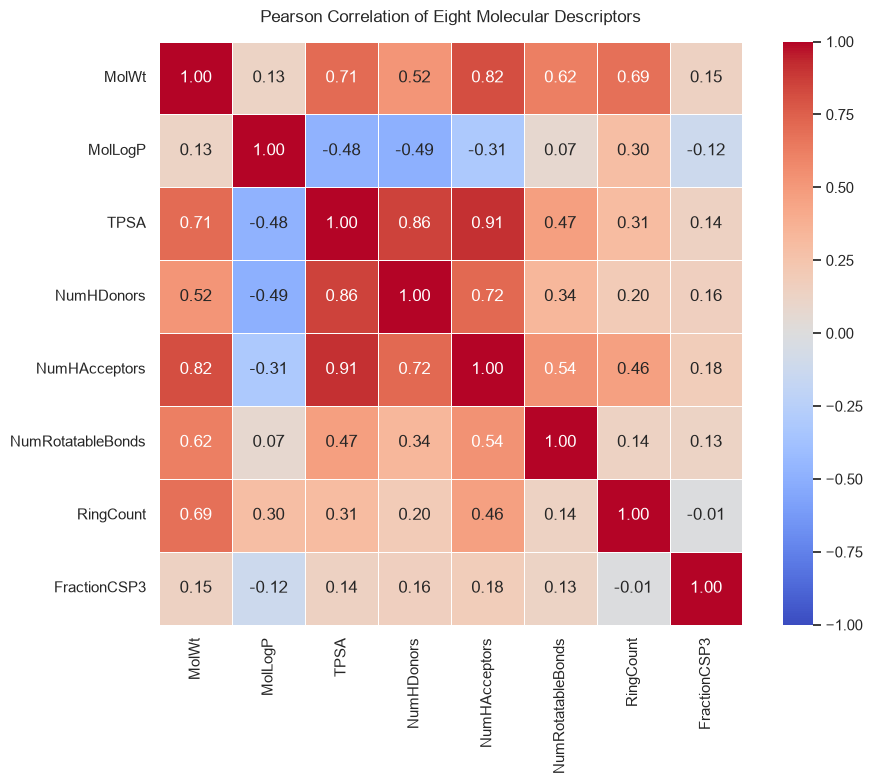

저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day2_descriptor_correlation.png


In [9]:
descriptor_correlation = descriptor_df.corr(method="pearson")
fig, axis = plt.subplots(figsize=(10, 8))
sns.heatmap(
    descriptor_correlation, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=axis,
)
axis.set_title("Pearson Correlation of Eight Molecular Descriptors", pad=14)
fig.tight_layout()
correlation_path = RESULTS_DIR / "day2_descriptor_correlation.png"
fig.savefig(correlation_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"저장 위치: {correlation_path}")

### 그래프에서 관찰한 사실

아래 내용은 최종 모델 후보 1,965개에서 보이는 **분포와 상관관계의 관찰**이며, BBB 투과의 원인이라고 단정하지 않습니다.

1. BBB+의 MolWt 중앙값은 약 308.57 g/mol이고 BBB-는 약 409.32 g/mol로, 이 데이터에서는 BBB+ 분포가 더 낮은 쪽에 모여 있습니다.
2. BBB+의 MolLogP 중앙값은 약 2.79이고 BBB-는 약 1.23으로, BBB+ 분포가 더 높은 쪽에 있습니다.
3. BBB+의 TPSA 중앙값은 약 47.89 Å²이고 BBB-는 약 111.10 Å²로, 두 클래스의 분포 위치가 눈에 띄게 다릅니다.
4. 8개 descriptor 중 TPSA와 NumHAcceptors의 양의 상관이 가장 크게 관찰되었고(`r ≈ 0.91`), TPSA와 NumHDonors도 강한 양의 상관을 보였습니다(`r ≈ 0.86`).

## 10. Morgan fingerprint 생성

Descriptor와 fingerprint는 모두 분자를 숫자로 바꾸지만 표현 방법이 다릅니다.

| 구분 | Descriptor | Morgan fingerprint |
|---|---|---|
| 형태 | 의미가 정해진 8개 연속 숫자 | 2,048개의 0/1 bit |
| 예시 | 분자량, LogP, TPSA | 특정 원자 주변 구조가 있으면 일부 bit가 1 |
| 해석 | 각 열의 의미가 비교적 명확함 | 개별 bit의 생물학적 의미를 바로 해석하기 어려움 |
| 장점 | 단순하고 설명하기 쉬움 | 다양한 국소 구조 패턴을 자세히 표현함 |

`radius=2`는 각 원자를 중심으로 최대 두 결합 거리까지 주변 구조를 본다는 뜻이고, `fpSize=2048`은 결과를 2,048개의 bit로 표현한다는 뜻입니다. RDKit의 현재 `rdFingerprintGenerator.GetMorganGenerator` 방식을 사용합니다.

### Fingerprint 행렬 생성과 검사

**입력:** 최종 모델용 1,965개 RDKit 분자입니다.  
**출력:** 각 행이 분자 하나이고 각 열이 bit 하나인 1,965 × 2,048 NumPy 행렬을 만듭니다. 값이 0과 1뿐인지 확인하고 첫 번째 분자의 활성 bit 수를 출력합니다. 전체 행렬은 크고 Day 3에 같은 코드로 재생성할 수 있으므로 CSV로 저장하지 않습니다.

In [10]:
MORGAN_RADIUS = 2
MORGAN_FP_SIZE = 2048

def generate_morgan_matrix(molecules, radius=2, fp_size=2048):
    """RDKit Mol 목록을 0/1 Morgan fingerprint NumPy 행렬로 변환합니다."""
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fp_size)
    matrix = np.zeros((len(molecules), fp_size), dtype=np.uint8)
    for row_index, mol in enumerate(molecules):
        fingerprint = generator.GetFingerprint(mol)
        row = np.zeros(fp_size, dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fingerprint, row)
        matrix[row_index] = row
    return matrix

fingerprint_matrix = generate_morgan_matrix(
    final_model_df["mol"].tolist(), radius=MORGAN_RADIUS, fp_size=MORGAN_FP_SIZE
)
fingerprint_shape = fingerprint_matrix.shape
fingerprint_unique_values = np.unique(fingerprint_matrix)
fingerprint_is_binary = set(fingerprint_unique_values.tolist()).issubset({0, 1})
example_active_bits = int(fingerprint_matrix[0].sum())
example_name = final_model_df.loc[0, "name"]

assert fingerprint_shape == (final_model_count, MORGAN_FP_SIZE)
assert fingerprint_is_binary

print(f"Morgan fingerprint 행렬 shape: {fingerprint_shape}")
print(f"행렬의 고유값: {fingerprint_unique_values.tolist()}")
print(f"0과 1로만 구성됨: {fingerprint_is_binary}")
print(f"예시 분자 '{example_name}'의 활성 bit 수: {example_active_bits}")
print("전체 2,048-bit 행렬은 CSV로 저장하지 않았습니다.")

Morgan fingerprint 행렬 shape: (1965, 2048)
행렬의 고유값: [0, 1]
0과 1로만 구성됨: True
예시 분자 'Propanolol'의 활성 bit 수: 36
전체 2,048-bit 행렬은 CSV로 저장하지 않았습니다.


## 11. 최종 모델 입력 구조 요약과 검증

**입력:** 데이터 선정 과정의 모든 개수, 최종 라벨 분포, descriptor와 fingerprint shape입니다.  
**출력:** Day 3에 사용할 입력 구조를 한 표로 출력하고, 원본 행 수가 모든 제외 사유와 최종 행 수의 합과 정확히 일치하는지 assert로 검증합니다.

In [11]:
final_input_summary = pd.DataFrame(
    [
        {"항목": "원본 분자 수", "값": f"{original_count:,}"},
        {"항목": "RDKit 파싱 성공 수", "값": f"{parse_success_count:,}"},
        {"항목": "파싱 실패 수", "값": f"{parse_failure_count:,}"},
        {"항목": "Canonical SMILES 중복 그룹 수", "값": f"{duplicate_group_count:,}"},
        {"항목": "동일 라벨 중복으로 제외된 수", "값": f"{same_label_duplicate_excluded:,}"},
        {"항목": "라벨 충돌로 제외된 수", "값": f"{conflicting_rows_excluded:,}"},
        {"항목": "최종 모델용 분자 수", "값": f"{final_model_count:,}"},
        {"항목": "최종 BBB+ 수와 비율", "값": f"{final_bbb_plus_count:,} ({final_bbb_plus_percent:.2f}%)"},
        {"항목": "최종 BBB- 수와 비율", "값": f"{final_bbb_minus_count:,} ({final_bbb_minus_percent:.2f}%)"},
        {"항목": "Descriptor 행렬 shape", "값": str(descriptor_shape)},
        {"항목": "Morgan fingerprint 행렬 shape", "값": str(fingerprint_shape)},
    ]
)
display(final_input_summary)

assert original_count == parse_failure_count + same_label_duplicate_excluded + conflicting_rows_excluded + final_model_count
assert final_bbb_plus_count + final_bbb_minus_count == final_model_count
assert descriptor_shape == (final_model_count, 8)
assert fingerprint_shape == (final_model_count, 2048)
assert not (PROJECT_ROOT / "BBBP.csv").exists(), "원본 BBBP.csv가 저장소 루트에 생성되었습니다."

required_outputs = [
    duplicate_path, conflict_path, cleaning_summary_path, descriptor_summary_path,
    distribution_path, correlation_path,
]
assert all(path.exists() for path in required_outputs), "Day 2 결과 파일 중 생성되지 않은 파일이 있습니다."

print("검증 통과: 원본 행 수 = 파싱 실패 + 동일 라벨 중복 제외 + 충돌 제외 + 최종 모델용 행 수")
print(f"{original_count:,} = {parse_failure_count:,} + {same_label_duplicate_excluded:,} + {conflicting_rows_excluded:,} + {final_model_count:,}")
print("데이터 분할, 스케일링과 모델 학습은 수행하지 않았습니다.")

,항목,값
0,원본 분자 수,"2,050"
1,RDKit 파싱 성공 수,"2,039"
2,파싱 실패 수,11
3,Canonical SMILES 중복 그룹 수,60
4,동일 라벨 중복으로 제외된 수,54
5,라벨 충돌로 제외된 수,20
6,최종 모델용 분자 수,"1,965"
7,최종 BBB+ 수와 비율,"1,500 (76.34%)"
8,최종 BBB- 수와 비율,465 (23.66%)
9,Descriptor 행렬 shape,"(1965, 8)"


검증 통과: 원본 행 수 = 파싱 실패 + 동일 라벨 중복 제외 + 충돌 제외 + 최종 모델용 행 수
2,050 = 11 + 54 + 20 + 1,965
데이터 분할, 스케일링과 모델 학습은 수행하지 않았습니다.
